In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

In [2]:
RESULTS_PATH = Path("../data/results")

phase9_df = pd.read_csv(
    RESULTS_PATH / "phase9_crisis_regime_dataset.csv",
    parse_dates=["date"]
)

lag_df = pd.read_csv(
    RESULTS_PATH / "phase9_lag_analysis.csv"
)

top_stress_periods = pd.read_csv(
    RESULTS_PATH / "phase9_top_stress_periods.csv",
    parse_dates=["date"]
)

In [3]:
RESULTS_PATH = Path("../data/results")

phase9_df = pd.read_csv(
    RESULTS_PATH / "phase9_crisis_regime_dataset.csv",
    parse_dates=["date"]
)

lag_df = pd.read_csv(
    RESULTS_PATH / "phase9_lag_analysis.csv"
)

top_stress_periods = pd.read_csv(
    RESULTS_PATH / "phase9_top_stress_periods.csv",
    parse_dates=["date"]
)

In [4]:
print("Phase 9 dataset:", phase9_df.shape)
print("Lag dataset:", lag_df.shape)
print("Stress periods:", top_stress_periods.shape)

Phase 9 dataset: (120, 20)
Lag dataset: (30, 2)
Stress periods: (20, 5)


In [5]:
phase9_df.head()

,date,market_return,market_volatility,drawdown,return_dispersion,nodes,edges,density,average_degree,average_clustering,connected_components,total_impact,affected_companies,market_stress_index,network_stress_index,systemic_stress_index,stress_regime,structural_break,early_warning,future_stress_event
0,2021-11-12 05:00:00,0.010352,0.008929,-0.012240,0.018532,10,8,0.177778,1.6,0.200000,5,0.371987,4.0,NaN,NaN,NaN,Unknown,False,False,True
1,2021-11-29 05:00:00,0.019308,0.012146,-0.014845,0.022200,10,9,0.200000,1.8,0.433333,5,0.379675,4.0,NaN,NaN,NaN,Unknown,False,False,True
2,2021-12-13 05:00:00,-0.019896,0.015810,-0.029956,0.022799,10,9,0.200000,1.8,0.433333,5,0.316338,3.0,1.036087,NaN,NaN,Unknown,False,False,True
3,2021-12-28 05:00:00,-0.003042,0.017217,-0.003042,0.007454,10,9,0.200000,1.8,0.333333,5,0.368796,4.0,0.232358,NaN,NaN,Unknown,False,False,True
4,2022-01-11 05:00:00,0.011002,0.015999,-0.036684,0.007603,10,9,0.200000,1.8,0.333333,5,0.372342,4.0,-0.032187,NaN,NaN,Unknown,False,False,True


In [6]:
phase9_df = phase9_df.sort_values(
    "date"
).reset_index(drop=True)

In [7]:
print(
    phase9_df[
        "date"
    ].min()
)

print(
    phase9_df[
        "date"
    ].max()
)

2021-11-12 05:00:00
2026-08-13 04:00:00


In [9]:
phase9_df.isna().sum()

date                      0
market_return             0
market_volatility         0
drawdown                  0
return_dispersion         0
nodes                     0
edges                     0
density                   0
average_degree            0
average_clustering        0
connected_components      0
total_impact              0
affected_companies        0
market_stress_index       2
network_stress_index     59
systemic_stress_index    59
stress_regime             0
structural_break          0
early_warning             0
future_stress_event       0
dtype: int64

In [10]:
phase10_df = phase9_df.dropna(
    subset=[
        "market_stress_index",
        "network_stress_index",
        "systemic_stress_index"
    ]
).copy()

In [11]:
phase10_df = phase10_df.reset_index(
    drop=True
)

In [12]:
HORIZON = 10

In [13]:
stress_threshold = (
    phase10_df[
        "systemic_stress_index"
    ].quantile(0.90)
)

print(
    "Systemic stress threshold:",
    stress_threshold
)

Systemic stress threshold: 0.902455020475407


In [18]:
future_stress = (
    phase10_df[
        "systemic_stress_index"
    ]
    .shift(-1)
    .rolling(
        HORIZON,
        min_periods=1
    )
    .max()
    .shift(
        -(HORIZON - 1)
    )
)

In [19]:
phase10_df[
    "future_max_stress"
] = future_stress

In [21]:
phase10_df[
    [
        "date",
        "systemic_stress_index",
        "future_max_stress"
    ]
].head(20)

,date,systemic_stress_index,future_max_stress
0,2024-03-21 04:00:00,-0.753866,0.343968
1,2024-04-05 04:00:00,-0.901105,0.343968
2,2024-04-19 04:00:00,-0.586039,0.343968
3,2024-05-03 04:00:00,-0.393839,0.343968
4,2024-05-17 04:00:00,-0.918864,0.343968
5,2024-06-03 04:00:00,-0.997626,0.343968
6,2024-06-17 04:00:00,-0.930604,0.343968
7,2024-07-02 04:00:00,-0.525962,0.343968
8,2024-07-17 04:00:00,-0.244626,0.343968
9,2024-07-31 04:00:00,0.343968,0.276468


In [22]:
phase10_df[
    "future_stress_event"
] = (
    phase10_df[
        "future_max_stress"
    ] >= stress_threshold
)

In [23]:
phase10_df[
    "future_stress_event"
].value_counts()

future_stress_event
False    45
True     16
Name: count, dtype: int64

In [24]:
phase10_df = phase10_df.dropna(
    subset=[
        "future_max_stress"
    ]
).copy()

In [25]:
phase10_df.reset_index(
    drop=True,
    inplace=True
)

In [26]:
target_counts = (
    phase10_df[
        "future_stress_event"
    ].value_counts()
)

print(target_counts)

future_stress_event
False    36
True     16
Name: count, dtype: int64


In [27]:
target_percentage = (
    phase10_df[
        "future_stress_event"
    ].mean()
    * 100
)

print(
    f"Future stress events: "
    f"{target_percentage:.2f}%"
)

Future stress events: 30.77%


In [28]:
warning_features = [
    "market_volatility",
    "drawdown",
    "return_dispersion",

    "edges",
    "density",
    "average_degree",
    "average_clustering",

    "total_impact",
    "affected_companies",

    "market_stress_index",
    "network_stress_index",
    "systemic_stress_index"
]

In [29]:
available_features = [
    feature
    for feature in warning_features
    if feature in phase10_df.columns
]

print(available_features)

['market_volatility', 'drawdown', 'return_dispersion', 'edges', 'density', 'average_degree', 'average_clustering', 'total_impact', 'affected_companies', 'market_stress_index', 'network_stress_index', 'systemic_stress_index']


In [30]:
phase10_df[
    "network_stress_lag_1"
] = phase10_df[
    "network_stress_index"
].shift(1)

phase10_df[
    "network_stress_lag_5"
] = phase10_df[
    "network_stress_index"
].shift(5)

phase10_df[
    "network_stress_lag_10"
] = phase10_df[
    "network_stress_index"
].shift(10)

In [32]:
phase10_df[
    "network_stress_change"
] = (
    phase10_df[
        "network_stress_index"
    ].diff()
)

In [33]:
phase10_df[
    "market_stress_change"
] = (
    phase10_df[
        "market_stress_index"
    ].diff()
)

In [34]:
phase10_df[
    "systemic_stress_change"
] = (
    phase10_df[
        "systemic_stress_index"
    ].diff()
)

In [35]:
phase10_df[
    "network_stress_momentum_5"
] = (
    phase10_df[
        "network_stress_index"
    ]
    .diff(5)
)

In [36]:
phase10_df[
    "market_stress_momentum_5"
] = (
    phase10_df[
        "market_stress_index"
    ]
    .diff(5)
)

In [37]:
ews_features = [
    "market_volatility",
    "drawdown",
    "return_dispersion",

    "density",
    "average_degree",
    "average_clustering",

    "total_impact",
    "affected_companies",

    "market_stress_index",
    "network_stress_index",
    "systemic_stress_index",

    "network_stress_lag_1",
    "network_stress_lag_5",
    "network_stress_lag_10",

    "network_stress_change",
    "market_stress_change",
    "systemic_stress_change",

    "network_stress_momentum_5",
    "market_stress_momentum_5"
]

In [38]:
phase10_model_df = phase10_df.dropna(
    subset=ews_features + [
        "future_stress_event"
    ]
).copy()

In [40]:
phase10_model_df.reset_index(
    drop=True,
    inplace=True
)

In [41]:
print(
    "Final EWS dataset:",
    phase10_model_df.shape
)

Final EWS dataset: (42, 29)


In [42]:
volatility_threshold = (
    phase10_model_df[
        "market_volatility"
    ].quantile(0.90)
)

In [43]:
phase10_model_df[
    "volatility_warning"
] = (
    phase10_model_df[
        "market_volatility"
    ] >= volatility_threshold
)

In [44]:
def evaluate_warning(
    y_true,
    y_pred,
    score=None
):

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    result = {
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    if score is not None:

        result["roc_auc"] = roc_auc_score(
            y_true,
            score
        )

    return result

In [45]:
y_true = (
    phase10_model_df[
        "future_stress_event"
    ].astype(int)
)

volatility_results = evaluate_warning(
    y_true,
    phase10_model_df[
        "volatility_warning"
    ].astype(int),
    phase10_model_df[
        "market_volatility"
    ]
)

In [46]:
print(
    "Volatility Baseline"
)

print(volatility_results)

Volatility Baseline
{'precision': 0.8, 'recall': 0.25, 'f1': 0.38095238095238093, 'roc_auc': 0.8076923076923077}


In [47]:
drawdown_stress = (
    -phase10_model_df[
        "drawdown"
    ]
)

In [48]:
drawdown_threshold = (
    drawdown_stress.quantile(0.90)
)

In [49]:
phase10_model_df[
    "drawdown_warning"
] = (
    drawdown_stress
    >= drawdown_threshold
)

In [50]:
drawdown_results = evaluate_warning(
    y_true,
    phase10_model_df[
        "drawdown_warning"
    ].astype(int),
    drawdown_stress
)

In [51]:
print(
    "Drawdown Baseline"
)

print(drawdown_results)

Drawdown Baseline
{'precision': 0.6, 'recall': 0.1875, 'f1': 0.2857142857142857, 'roc_auc': 0.5745192307692308}


In [52]:
network_threshold = (
    phase10_model_df[
        "network_stress_index"
    ].quantile(0.90)
)

In [53]:
phase10_model_df[
    "network_warning"
] = (
    phase10_model_df[
        "network_stress_index"
    ] >= network_threshold
)

In [54]:
network_results = evaluate_warning(
    y_true,
    phase10_model_df[
        "network_warning"
    ].astype(int),
    phase10_model_df[
        "network_stress_index"
    ]
)

In [55]:
print(
    "Network Baseline"
)

print(network_results)

Network Baseline
{'precision': 1.0, 'recall': 0.3125, 'f1': 0.47619047619047616, 'roc_auc': 0.7427884615384615}


In [56]:
from sklearn.preprocessing import MinMaxScaler

In [57]:
score_components = phase10_model_df[
    [
        "market_stress_index",
        "network_stress_index",
        "total_impact",
        "affected_companies"
    ]
].copy()

In [58]:
scaler = MinMaxScaler()

scaled_components = scaler.fit_transform(
    score_components
)

In [59]:
scaled_components_df = pd.DataFrame(
    scaled_components,
    columns=[
        "market_component",
        "network_component",
        "contagion_component",
        "affected_component"
    ],
    index=phase10_model_df.index
)

In [60]:
phase10_model_df[
    "ews_score"
] = (
    0.25 *
    scaled_components_df[
        "market_component"
    ]

    +

    0.30 *
    scaled_components_df[
        "network_component"
    ]

    +

    0.30 *
    scaled_components_df[
        "contagion_component"
    ]

    +

    0.15 *
    scaled_components_df[
        "affected_component"
    ]
)

In [61]:
ews_threshold = (
    phase10_model_df[
        "ews_score"
    ].quantile(0.90)
)

In [62]:
phase10_model_df[
    "ews_warning"
] = (
    phase10_model_df[
        "ews_score"
    ] >= ews_threshold
)

In [63]:
ews_results = evaluate_warning(
    y_true,
    phase10_model_df[
        "ews_warning"
    ].astype(int),
    phase10_model_df[
        "ews_score"
    ]
)

In [64]:
print(
    "FinGraph-Sentinel Early Warning System"
)

print(ews_results)

FinGraph-Sentinel Early Warning System
{'precision': 1.0, 'recall': 0.3125, 'f1': 0.47619047619047616, 'roc_auc': 0.6778846153846154}


In [66]:
comparison_df = pd.DataFrame({

    "Model": [
        "Volatility",
        "Drawdown",
        "Network",
        "FinGraph-Sentinel EWS"
    ],

    "Precision": [
        volatility_results["precision"],
        drawdown_results["precision"],
        network_results["precision"],
        ews_results["precision"]
    ],

    "Recall": [
        volatility_results["recall"],
        drawdown_results["recall"],
        network_results["recall"],
        ews_results["recall"]
    ],

    "F1": [
        volatility_results["f1"],
        drawdown_results["f1"],
        network_results["f1"],
        ews_results["f1"]
    ],

    "ROC-AUC": [
        volatility_results["roc_auc"],
        drawdown_results["roc_auc"],
        network_results["roc_auc"],
        ews_results["roc_auc"]
    ]
})

In [67]:
comparison_df

,Model,Precision,Recall,F1,ROC-AUC
0,Volatility,0.8,0.2500,0.380952,0.807692
1,Drawdown,0.6,0.1875,0.285714,0.574519
2,Network,1.0,0.3125,0.476190,0.742788
3,FinGraph-Sentinel EWS,1.0,0.3125,0.476190,0.677885


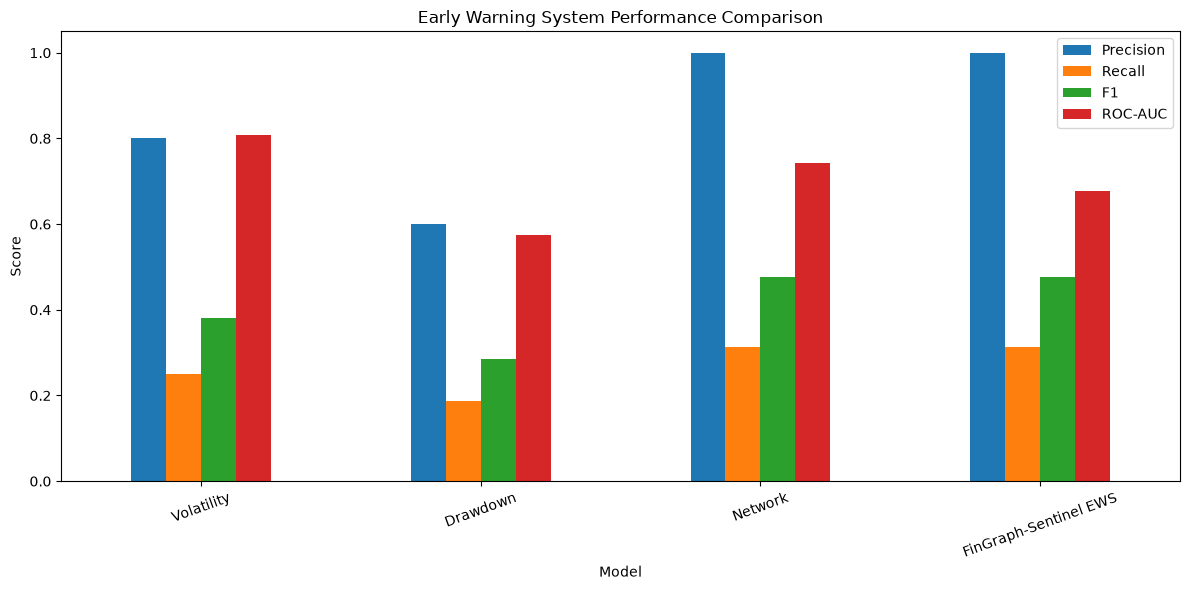

In [68]:
comparison_df.set_index(
    "Model"
)[
    [
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Early Warning System Performance Comparison"
)

plt.ylabel("Score")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

In [69]:
threshold_results = []

for threshold in np.linspace(
    0.1,
    0.9,
    81
):

    prediction = (
        phase10_model_df[
            "ews_score"
        ] >= threshold
    )

    precision = precision_score(
        y_true,
        prediction,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        prediction,
        zero_division=0
    )

    threshold_results.append({

        "threshold": threshold,

        "precision": precision,

        "recall": recall,

        "f1": f1
    })

In [70]:
threshold_df = pd.DataFrame(
    threshold_results
)

In [71]:
best_threshold_row = (
    threshold_df
    .loc[
        threshold_df[
            "f1"
        ].idxmax()
    ]
)

In [72]:
print(
    "Optimal threshold:",
    best_threshold_row[
        "threshold"
    ]
)

print(
    "Best F1:",
    best_threshold_row[
        "f1"
    ]
)

Optimal threshold: 0.16
Best F1: 0.6190476190476191


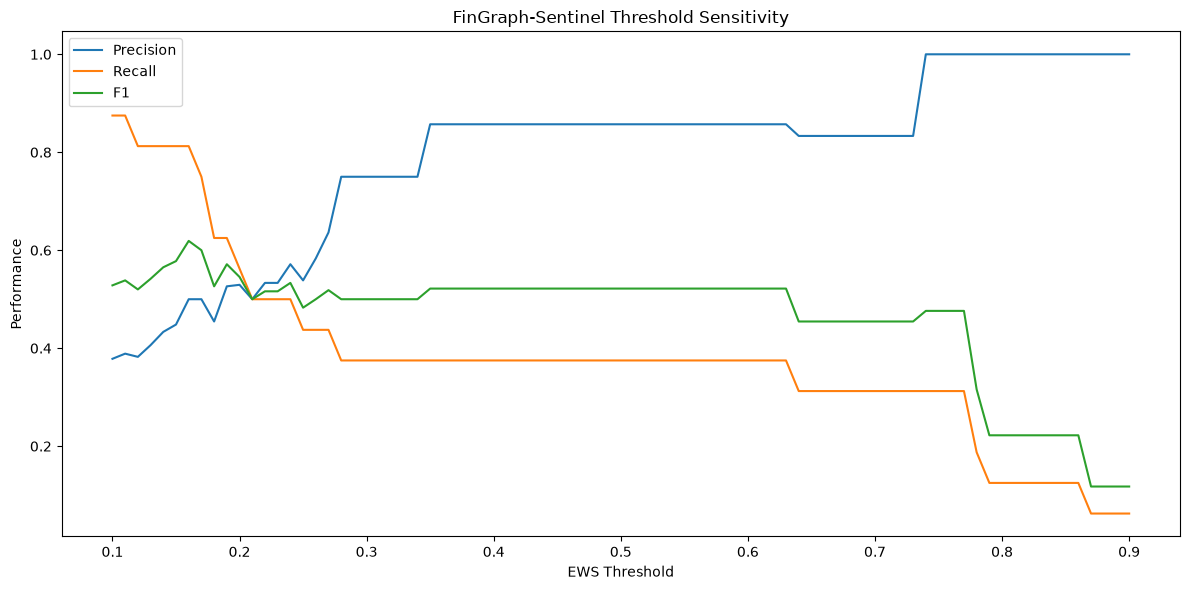

In [73]:
plt.figure(figsize=(12, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    label="F1"
)

plt.xlabel(
    "EWS Threshold"
)

plt.ylabel(
    "Performance"
)

plt.title(
    "FinGraph-Sentinel Threshold Sensitivity"
)

plt.legend()

plt.tight_layout()

plt.show()

In [74]:
optimal_threshold = (
    best_threshold_row[
        "threshold"
    ]
)

In [75]:
phase10_model_df[
    "final_ews_warning"
] = (
    phase10_model_df[
        "ews_score"
    ] >= optimal_threshold
)

In [76]:
final_ews_results = evaluate_warning(
    y_true,
    phase10_model_df[
        "final_ews_warning"
    ].astype(int),
    phase10_model_df[
        "ews_score"
    ]
)

In [77]:
print(
    "FINAL FIN-GRAPH SENTINEL EWS"
)

for metric, value in final_ews_results.items():

    print(
        f"{metric}: {value:.4f}"
    )

FINAL FIN-GRAPH SENTINEL EWS
precision: 0.5000
recall: 0.8125
f1: 0.6190
roc_auc: 0.6779


In [78]:
stress_dates = phase10_model_df.loc[
    phase10_model_df[
        "future_stress_event"
    ],
    "date"
].tolist()

In [79]:
warning_dates = phase10_model_df.loc[
    phase10_model_df[
        "final_ews_warning"
    ],
    "date"
].tolist()

In [80]:
lead_times = []

for stress_date in stress_dates:

    previous_warnings = [
        warning_date
        for warning_date in warning_dates
        if warning_date < stress_date
    ]

    if previous_warnings:

        latest_warning = max(
            previous_warnings
        )

        lead_time = (
            stress_date
            - latest_warning
        ).days

        lead_times.append(
            lead_time
        )

In [81]:
if lead_times:

    print(
        "Average warning lead time:",
        np.mean(lead_times)
    )

    print(
        "Median warning lead time:",
        np.median(lead_times)
    )

    print(
        "Maximum warning lead time:",
        np.max(lead_times)
    )

Average warning lead time: 18.3125
Median warning lead time: 14.5
Maximum warning lead time: 43


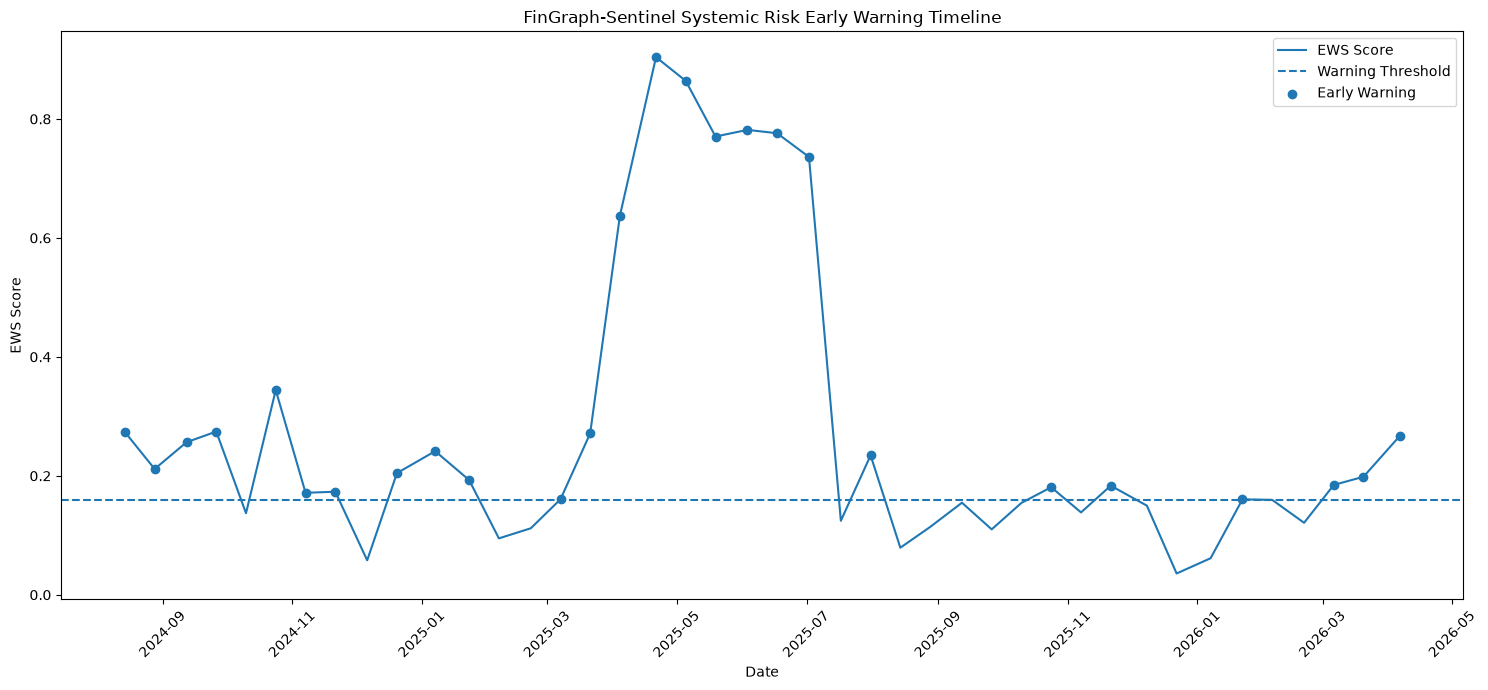

In [82]:
plt.figure(figsize=(15, 7))

plt.plot(
    phase10_model_df["date"],
    phase10_model_df["ews_score"],
    label="EWS Score"
)

plt.axhline(
    optimal_threshold,
    linestyle="--",
    label="Warning Threshold"
)

warning_points = (
    phase10_model_df[
        phase10_model_df[
            "final_ews_warning"
        ]
    ]
)

plt.scatter(
    warning_points["date"],
    warning_points["ews_score"],
    label="Early Warning"
)

plt.xlabel("Date")
plt.ylabel("EWS Score")

plt.title(
    "FinGraph-Sentinel Systemic Risk Early Warning Timeline"
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [83]:
def risk_level(score):

    if score < 0.25:
        return "Low"

    elif score < 0.50:
        return "Moderate"

    elif score < 0.75:
        return "High"

    else:
        return "Critical"

In [84]:
phase10_model_df[
    "risk_level"
] = phase10_model_df[
    "ews_score"
].apply(
    risk_level
)

In [85]:
phase10_model_df[
    [
        "date",
        "ews_score",
        "risk_level",
        "final_ews_warning"
    ]
].tail(20)

,date,ews_score,risk_level,final_ews_warning
22,2025-07-02 04:00:00,0.736123,High,True
23,2025-07-17 04:00:00,0.124369,Low,False
24,2025-07-31 04:00:00,0.234378,Low,True
25,2025-08-14 04:00:00,0.079129,Low,False
26,2025-08-28 04:00:00,0.113927,Low,False
27,2025-09-12 04:00:00,0.154773,Low,False
28,2025-09-26 04:00:00,0.109980,Low,False
29,2025-10-10 04:00:00,0.154454,Low,False
30,2025-10-24 04:00:00,0.180877,Low,True
31,2025-11-07 05:00:00,0.138456,Low,False


In [86]:
risk_summary = (
    phase10_model_df[
        "risk_level"
    ]
    .value_counts()
    .rename_axis("risk_level")
    .reset_index(
        name="observations"
    )
)

In [87]:
risk_summary

,risk_level,observations
0,Low,29
1,Moderate,6
2,Critical,5
3,High,2


In [88]:
top_warning_periods = (
    phase10_model_df
    .sort_values(
        "ews_score",
        ascending=False
    )
    [
        [
            "date",
            "ews_score",
            "risk_level",
            "market_stress_index",
            "network_stress_index",
            "total_impact",
            "affected_companies"
        ]
    ]
    .head(20)
)

In [89]:
top_warning_periods

,date,ews_score,risk_level,market_stress_index,network_stress_index,total_impact,affected_companies
17,2025-04-21 04:00:00,0.903966,Critical,0.812467,2.692961,0.835569,10.0
18,2025-05-05 04:00:00,0.864007,Critical,0.259093,2.806453,0.851085,10.0
20,2025-06-03 04:00:00,0.781689,Critical,-0.603724,2.630401,0.891127,10.0
21,2025-06-17 04:00:00,0.776004,Critical,-0.577193,2.547688,0.886433,10.0
19,2025-05-19 04:00:00,0.770487,Critical,-0.643127,2.692063,0.863574,10.0
22,2025-07-02 04:00:00,0.736123,High,-0.304601,2.109511,0.808666,10.0
16,2025-04-04 04:00:00,0.637418,High,1.445146,1.162070,0.498029,6.0
5,2024-10-24 04:00:00,0.344110,Moderate,1.224090,-0.671154,0.310200,3.0
3,2024-09-26 04:00:00,0.274445,Moderate,-0.689624,-0.165258,0.425019,5.0
0,2024-08-14 04:00:00,0.273573,Moderate,0.647392,-0.824368,0.307454,3.0


In [90]:
phase10_model_df.to_csv(
    RESULTS_PATH /
    "phase10_early_warning_dataset.csv",
    index=False
)

In [91]:
comparison_df.to_csv(
    RESULTS_PATH /
    "phase10_model_comparison.csv",
    index=False
)

In [92]:
threshold_df.to_csv(
    RESULTS_PATH /
    "phase10_threshold_analysis.csv",
    index=False
)

In [93]:
top_warning_periods.to_csv(
    RESULTS_PATH /
    "phase10_top_warning_periods.csv",
    index=False
)

In [94]:
risk_summary.to_csv(
    RESULTS_PATH /
    "phase10_risk_summary.csv",
    index=False
)

In [95]:
print("=" * 70)
print("FIN-GRAPH-SENTINEL — PHASE 10 VALIDATION")
print("=" * 70)

print(
    "\nDataset shape:",
    phase10_model_df.shape
)

print(
    "\nStress threshold:",
    stress_threshold
)

print(
    "EWS threshold:",
    optimal_threshold
)

print(
    "\nFINAL PERFORMANCE"
)

for metric, value in final_ews_results.items():

    print(
        f"{metric.upper():12}: {value:.4f}"
    )

print(
    "\nAverage lead time:",
    f"{np.mean(lead_times):.2f} days"
    if lead_times
    else "No warnings detected"
)

print(
    "\nRisk distribution:"
)

print(
    phase10_model_df[
        "risk_level"
    ].value_counts()
)

print("=" * 70)

FIN-GRAPH-SENTINEL — PHASE 10 VALIDATION

Dataset shape: (42, 36)

Stress threshold: 0.902455020475407
EWS threshold: 0.16

FINAL PERFORMANCE
PRECISION   : 0.5000
RECALL      : 0.8125
F1          : 0.6190
ROC_AUC     : 0.6779

Average lead time: 18.31 days

Risk distribution:
risk_level
Low         29
Moderate     6
Critical     5
High         2
Name: count, dtype: int64
